<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-header">

## Tutorial \#7: Recording

</div>

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Back in Tutorial \#4 we observed a brain by reading its state after every single step (and we promised ourselves not to do that too often, since GPU-CPU communication is expensive). Then, in Tutorial \#6, we trained a brain to balance the CartPole™ and we only looked at how many steps the pole stayed up.

However, <b><i>Spark</i></b> models learn continuously, and the interesting (and possibily important) questions are rarely about the final score. Ideally, we would like to start asking more complex questions: How often does each population fire? How do the membrane potentials move? How much are the weights changing? What was the network is  <i>seeing</i>?

<b><i>Spark</i></b> tries to answers such questions via the module <b>spark.recording</b>. This module can be used to record (almost) anything from any model while it runs relatively efficiently and without having to pay any cost whatsoever when we do not care about the current state of the cat.

So, let's run the CartPole™ once more, but this time let's record it!

</div>

In [1]:
# Imports
import tqdm
import numpy as np
import jax
import jax.numpy as jnp

import spark
import spark.recording as rec

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

As usual, we start by registering classes and building the brain.

</div>

In [2]:
NEURON_PATH = './alif_mod_neuron.scfg'
BRAIN_PATH = './ab_brain.scfg'

# Register the custom models
try:
	spark.register_neuron_from_config_file('ALIFModNeuron', NEURON_PATH)
except Exception as e:
	print(f'Oh no: {e}!')

# Load, reseed and build the brain
brain_config = spark.nn.BrainConfig.from_file(BRAIN_PATH).with_new_seeds(seed=42)
brain = spark.nn.Brain(config=brain_config)

# Build the brain
f16 = lambda v: spark.FloatArray(jnp.asarray(v, dtype=jnp.float16))
example_inputs = {
	'signal': f16(np.zeros(4)),
	**{name: f16([0.0]) for name in ('mod_a_ex', 'mod_a_in', 'mod_b_ex', 'mod_b_in')},
	**{name: f16([0.0]) for name in ('drift_ex', 'drift_in')},
}
_ = brain(**example_inputs)

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Next, as some chemist used to said: <i>"Give me a target and I'll give you the drug."</i>, In order to record anything, we first need to know what we want to record. 

In <b><i>Spark</i></b> this comes from the very same names used to wire the model. Here, we can either start guessing paths and names or we can simply ask the model using <b>spark.recording.get_probe_targets</b>. 

</div>

In [3]:
entries = rec.get_probe_targets(brain, example_inputs)
for entry in entries:
	print(entry)

__call__:drift_ex                                port      (1,)             float16  FloatArray     Brain
__call__:drift_in                                port      (1,)             float16  FloatArray     Brain
__call__:mod_a_ex                                port      (1,)             float16  FloatArray     Brain
__call__:mod_a_in                                port      (1,)             float16  FloatArray     Brain
__call__:mod_b_ex                                port      (1,)             float16  FloatArray     Brain
__call__:mod_b_in                                port      (1,)             float16  FloatArray     Brain
__call__:signal                                  port      (4,)             float16  FloatArray     Brain
A_excitatory.__call__:drift                      port      (1,)             float16  FloatArray     ALIFModNeuron
A_excitatory.__call__:modulation                 port      (1,)             float16  FloatArray     ALIFModNeuron
A_excitatory.__call__:in_spike

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Now, that with a name at hand we can star revealing its true nature. However, <i>revelations</i> are expensive and we may have to settle with just probing a variable with a <b>spark.recording.Probe</b>. Probes are straightforward to use, although they came in different "flavours", depending on what we want to record.

| probe | records |
|---|---|
| <b>SummaryProbe</b> | <b>mean</b>, <b>std</b>, <b>min</b>, <b>max</b>, <b>active_fraction</b> (fraction of nonzero values), <b>active_fraction_per_unit</b>, <b>inactive_unit_fraction</b> or <b>hist</b> over the chunk |
| <b>TraceProbe</b> | the value on every step, optionally for a subset of <b>units</b> and with a <b>stride</b> |
| <b>RasterProbe</b> | the nonzero entries on every step, packed as bits (perfect for spikes) |
| <b>SnapshotProbe</b> | an attribute at the end of the chunk |
| <b>DeltaProbe</b> | the change of an attribute over the chunk: <b>full</b>, <b>norm</b> or <b>mean_abs</b> |

</div>

In [4]:
probe = rec.SummaryProbe(						# <--- Use the probe to record summary statistics
	'A_excitatory.soma:spikes',					# <--- Target: The spikes of the soma of A_excitatory
	reduce=(
		rec.SummaryReduction.ACTIVE_FRACTION,	# <--- Compute the firing rate.
		rec.SummaryReduction.INACTIVE_UNIT_FRACTION,
	),
)

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Since, some experiments can be really expensive, we can validate the probes against the model, to avoid any future pain after a long run that lasted for several days but recorded anything (do not look at me, it could happen to anybody!).

</div>

In [5]:
# A good probe...
try: 
	rec.validate(brain, (probe,))
	print(f'Oh yes: {type(probe).__name__} of {probe.address}!')
except Exception as e:
	print(f'Oh no: {e}!')

# ... and a bad one.
try: 
	bad_probe = rec.SummaryProbe('A_excitatory.stoma:spikes')
	rec.validate(brain, (bad_probe,))
	print(f'Oh yes: {type(bad_probe).__name__} of {bad_probe.address}!')
except Exception as e:
	print(f'Oh no: {e}!')

Oh yes: SummaryProbe of A_excitatory.soma:spikes!
Oh no: No module "stoma" under A_excitatory for "A_excitatory.stoma:spikes". Available: drift_trace, reward_trace, delays, plasticity, soma, synapses.!


<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Writing probes by hand, for every population within the model, can get old fast. Rather than building every probe manually, <b><i>Spark</i></b>  offers <b>spark.recording.presets</b>, which proposes a reasonable set of probes from the model definition: 

1. <b>summary</b> Cheap summary statistics of the population (spikes, potentials, kernel sizes) 
2. <b>activity</b> General model activity (most inputs/ and outputs plust potentials) 
3. <b>weights</b> for tracking the synpatic kernels.

Note that these presets are mostly for debugging purposes and we still recommend hand-tailored probes for any real experiment.

</div>

In [6]:
for rec_preset in rec.presets.default(brain):
	print(f'{rec_preset.name:<9}')
	for probe in rec_preset.probes[:4]:
		print(f'    {type(probe).__name__:<14} {probe.address}')
	print(f'    ... {len(rec_preset.probes)} probes\n')

summary  
    SummaryProbe   A_excitatory.soma:spikes
    SummaryProbe   A_excitatory.soma.potential
    SummaryProbe   B_excitatory.soma:spikes
    SummaryProbe   B_excitatory.soma.potential
    ... 12 probes

activity 
    TraceProbe     __call__:drift_ex
    TraceProbe     __call__:mod_a_ex
    TraceProbe     __call__:mod_b_ex
    TraceProbe     __call__:drift_in
    ... 25 probes

weights  
    SnapshotProbe  A_excitatory.synapses.kernel
    SnapshotProbe  B_excitatory.synapses.kernel
    SnapshotProbe  A_inhibitory.synapses.kernel
    SnapshotProbe  B_inhibitory.synapses.kernel
    ... 4 probes



<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Although <b>spark.recording</b> makes recording straightforward, it still can slow down if we try to record everything, everywhere, all at once. Not to mention that we will drown in data before the model even had a chance to learn. As such, there is still a need to be conservative when recording data.

A <b>spark.recording.Measurements</b> puts a few probes together under a single name, or <i>measurement</i>. As any recorder, it should be trigger to start recording by means of <b>recorder.record(name, num_steps)</b>, which tracks the <i>name</i> measurements for the next <i>num_steps</i> steps. We still need to decide what to record: every 20 episodes, a few steps after something interesting happens, when the reward goes up/down, etc.

Summaries, snapshots and deltas turn many steps into a single record, so the measurements holding them also need a <b>group</b>: the steps each record covers. A number of steps, <b>group=100</b>, gives one record every 100 steps of the run; the name of a tag, <b>group='episode'</b>, gives one record per episode, however long each one was. Once a step of a group is recorded, the group is recorded until its end, so a record covers its whole group (unless it was recorded from halfway through one, or the run ended first; each record keeps the number of steps it covers anyway). This also means that asking for a single step as an episode starts, <b>recorder.record('per_episode')</b>, records the whole episode. Traces and rasters record every single step, so they need no group.

</div>

In [7]:
# Create a summary probe to track the firing rate and the fraction on dead neurons. 
spikes = rec.SummaryProbe(
	'A_excitatory.soma:spikes',
	reduce=(rec.SummaryReduction.ACTIVE_FRACTION, rec.SummaryReduction.INACTIVE_UNIT_FRACTION),
)

# Recorded only when we ask for it, one summary every 100 steps...
by_hand = rec.Measurements('by_hand', (spikes,), group=100)

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Additionally, the <i>measurement</i> can be schedule on regular patterns by means of a <b>trigger</b>. Under the hood, triggers count simulation steps, <b>rec.Every(1000, length=100)</b> records 100 steps out of every 1000 steps. Moreover, we can also provide a counting tag, such as <i>episodes</i>: <b>rec.Every(20, unit='episode')</b>, which records one episode out of every 20. <b>rec.Always()</b>, as it names suggest, sets the recorder to be always ON. 

</div>

In [8]:
# Record 100 steps out of every 1000 steps.
regular_measurement = rec.Measurements('regular', (spikes,), group=100, trigger=rec.Every(1000, length=100))

# ... or one episode out of every 20, one summary per episode.
episode_measurement = rec.Measurements('episode', (spikes,), group='episode', trigger=rec.Every(20, tag='episode'))

# ... or everything in collections of 100 steps.
drowning_measurement = rec.Measurements('drowning', (spikes,), group=100, trigger=rec.Always())

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Note that certain probes require us to specify the group parameters in order to perform (compute) the measurement.

</div>

In [9]:
# Summaries need a group.
try:
	rec.Measurements('oops', (spikes,))
except ValueError as e:
	print(f'Oh no: {e}!')

# ... while traces and rasters do not.
potentials = rec.Measurements(
	'potentials',
	(rec.TraceProbe('A_excitatory.soma.potential', units=range(8), stride=5),),	# <--- 8 neurons, every 5 steps
)
print(f'Oh yes: {potentials.name}!')

Oh no: Measurements "oops": A_excitatory.soma:spikes@summary give one record per group of steps; give "group", a number of steps or the name of a tag.!
Oh yes: potentials!


<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Note that the presets come with predefined triggers. However, for the sake of performance and the health of your storage device, we recommend to always construct the probes manually.

</div>

In [10]:
# The presets come with triggers and groups of their own, for runs that do not decide by hand.
for measurements in rec.presets.default(brain):
	print(f'{measurements.name:<9} {measurements.trigger}, group {measurements.group}')

summary   Always(tag=None), group 1000
activity  Every(tag=None, n=100000, length=1000, offset=0), group None
weights   Every(tag=None, n=100000, length=1, offset=99999), group 100000


<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Now, let's run the CartPole experiment again, but this time let's record <i>everything</i> from the training loop:

* <b>summary</b>, the population statistics of the preset, for every episode, one summary each.
* <b>episode</b>, every step of one episode out of 20: the spikes of every population, the potentials of 32 neurons per soma, the inputs, the reward and drift traces that drive plasticity, and the output of the integrator.
* <b>weights</b>, a snapshot of every kernel at the end of those same episodes.

Note that we by setting <b>group='episode'</b> we are asking the recorder to keep track of the entire episode, since its episode counter will increase after the episode is completed.

Some data never reaches the model at all, for example the observation of the environment before we scale it. We can still record it as <b>raw</b>: the recorder keeps a frame only while measurements that declare it are being recorded, and quietly drops it otherwise, so we can call it on every single environment step without a second thought.

</div>

In [11]:
# Summary metrics of the entire network
summary = rec.Measurements(
	'summary',
	rec.presets.summary(brain),											# <--- Rates, potentials and weight changes of every population
	group='episode',													# <--- One summary per episode
)

# Activity metrics  of the entire episode
episode = rec.Measurements(
	'episode',
	rec.presets.activity(brain, trace_units=32),						# <--- Spikes, 32 potentials per soma, inputs, traces
	group='episode',													# <--- Records the whole episode because rec.presets.activity returns TraceProbe
	raw=('env/observation',),
	views={'env/observation': {
        'kind': 'vector', 
        'labels': ['position', 'velocity', 'angle', 'angular velocity']
    }},
)

# Snapshots of the kernels after the end of the episode
weights = rec.Measurements(
	'weights',
	rec.presets.weights(brain),
	group='episode',
)
measurements = [summary, episode, weights]

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Now, for the training loop we are going to reuse the code from Tutorial \#6 as it is, with two new names: <b>spark.jit</b> where Tutorial \#6 used <b>jax.jit</b>, and <b>spark.scan</b> where it used <b>jax.lax.scan</b>. But first, the shared code.

</div>

In [12]:
# Cartpole metaparameters (same as Tutorial #6)
PASSIVE_MODULATION_SCALE = -0.0001
REWARD_FALL_SCALE = -25
REWARD_OOB_SCALE = -25
REWARD_OOB_THRESHOLD = 0.05
NEG_REWARD_SCALE = -0.1
MOD_INHIBITION_SCALE= 0.25
DT = 1
TRAIN_EPOCHES = 200
UNROLL = 1
STEPS = int(50/DT)
SEED = 42

In [13]:
# Utility function to preprocess information from the environment.
# This function just scale the observation environment to the (-1,1) range.
def process_obs(x):
	# CartPos, CartSpeed, PoleAngle, PoleAngSpeed
	x = x / np.array([2.4, 2.5, 0.2095, 3.5])
	return np.clip(x, a_min=-1, a_max=1)

# Utility method to simplify model ingestion.
def mod_inputs(signal, drift, mod_a=0.0, mod_b=0.0):
	f16 = lambda v: spark.FloatArray(jnp.array([v], dtype=jnp.float16))
	return {
		'signal': spark.FloatArray(jnp.array(signal, dtype=jnp.float16)),
		'mod_a_ex': f16(mod_a),
		'mod_a_in': f16(mod_a * MOD_INHIBITION_SCALE),
		'mod_b_ex': f16(mod_b),
		'mod_b_in': f16(mod_b * MOD_INHIBITION_SCALE),
		'drift_ex': f16(drift),
		'drift_in': f16(drift * MOD_INHIBITION_SCALE),
	}


def run_episode(env, graph, state, modulation_scale, steps, unroll):
	# Reset environment
	next_obs, _ = env.reset()
	rec.raw('env/observation', next_obs)
	next_obs = process_obs(next_obs)
	# Loop until the episode ends, either from failing or truncation
	terminated = False
	truncated = False
	episode_steps = 0
	# Allow the network to prepare for the episode.
	for _ in range(1):
		_, state = run_model_unroll(
			graph, state, steps=steps, unroll=unroll,
			**mod_inputs(np.zeros_like(next_obs), drift=0.0)
		)
	# Start episode
	while not (terminated or truncated):
		# Model logic, let the network do what it wants to do.
		out, state = run_model_unroll(
			graph, state, steps=steps, unroll=unroll,
			**mod_inputs(next_obs, drift=PASSIVE_MODULATION_SCALE * modulation_scale)
		)
		# Environment logic.
		next_action = int(np.argmax(out['action'].value))
		prev_episode = np.array(next_obs)
		next_obs, _, terminated, truncated, _ = env.step(next_action)
		rec.raw('env/observation', next_obs)
		next_obs = process_obs(next_obs)
		episode_steps += 1
	# Steer the network to what we want with one extra step with the last episode and the reward
	if not truncated:
		# Check if the agent went out of bounds.
		out_of_bounds = np.abs(next_obs[0]) >= 1
		# Critic-like action update
		# Going out of bounds conflicts with learning to balance the pole, adding a second condition
		# to check for the the pole to be mostly vertical improves learning speed 
		if out_of_bounds and np.abs(next_obs[2]) < REWARD_OOB_THRESHOLD:
			# If the cart went out of bounds, we need to move the cart towards the center
			# Going out of bounds is not as bad as the pole falling, so we should not put to much 
			# punishment towards that action
			steer_to_b = next_obs[0] < 0
			reward = REWARD_OOB_SCALE * modulation_scale
		else: 
			# If the pole fell, we need to move the cart towards the side it fell
			steer_to_b = next_obs[2] > 0
			reward = REWARD_FALL_SCALE * modulation_scale
		mod_a = reward if steer_to_b else NEG_REWARD_SCALE * reward
		mod_b = reward if not steer_to_b else NEG_REWARD_SCALE * reward
		# The reward is delivered once. The accumulator inside the neuron carries it through the
		# rest of the interaction window.
		for _ in range(1):
			_, state = run_model_unroll(
				graph, state, steps=steps, unroll=unroll,
				**mod_inputs(prev_episode, drift=0.0, mod_a=mod_a, mod_b=mod_b)
			)
	else:
		out_of_bounds = False
	if out_of_bounds:
		outcome = 'out of bounds'
	elif truncated:
		outcome = 'truncated'
	else:
		outcome = 'fell'
	return state, episode_steps, outcome

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

* Without an open recorder, <b>spark.jit</b> and <b>spark.scan</b> are <b>jax.jit</b> and <b>jax.lax.scan</b>, and our function compiles to the very same program as in Tutorial \#6.

* While a recorder is open, every call of our function is also a call of the recorder. Before the call, the recorder decides what to record over its steps, and <b>spark.scan</b> records it along the way. After the call, the records are handed over to the recorder, without waiting for them to leave the GPU. Each combination of recorded measurements compiles once.

</div>

In [14]:
from functools import partial

@partial(spark.jit, static_argnames=['steps', 'unroll'])			# <--- jax.jit in Tutorial #6
def run_model_unroll(graph, state, steps, unroll=15, **inputs):
    # Reward "reaches" the network only once and then the trace carries it through 
	# the rest of the interaction window
    reward_keys = ('mod_a_ex', 'mod_a_in', 'mod_b_ex', 'mod_b_in')
    delivered_once = jnp.zeros((steps,), dtype=jnp.float32).at[0].set(1.0)
    rewards = {
        key: (
            inputs[key].value.astype(jnp.float32)[None, :] * delivered_once[:, None]
		).astype(jnp.float16) for key in reward_keys
	}
    held_inputs = {
        key: value for key, value in inputs.items() if key not in reward_keys
	}
    def step_fn(model_state, reward_slice):
        # Merge model
        model = spark.merge(graph, model_state)
        # Run model. Append the reward to inputs.
        out = model(**held_inputs, **{key: spark.FloatArray(value) for key, value in reward_slice.items()})
        # Get new state
        _, new_state = spark.split((model))
        return new_state, out
    # Run the scan loop
    final_state, stacked_outs = spark.scan(
        step_fn, 
        state, 
        xs=rewards, 
        length=steps, 
        unroll=unroll
	)
    # Retrieve model output
    final_out = jax.tree.map(lambda x: x[-1], stacked_outs)
    return final_out, final_state

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Time to train! The recorder creates a new run directory inside <b>runs/</b> and writes everything needed to understand the run later: the configuration of the model (including the layout of the Graph Editor, thanks to <b>source</b>), our metaparameters, the git commit of the code and the environment it ran in.

The first call recording a new combination of measurements compiles it. Here, the first episode compiles the call recording all three, and the second episode the call recording the summary alone. Every later call reuses one of the two.

</div>

In [15]:
import gymnasium as gym

# Initialize the environment
env_name =  'CartPole-v1'
env = gym.make(env_name, sutton_barto_reward=True)
next_obs, _ = env.reset(seed=SEED)
next_obs = process_obs(next_obs)

In [16]:
# Load the brain configuration
brain_config = spark.nn.BrainConfig.from_file(BRAIN_PATH)

# Reseed
brain_config = brain_config.with_new_seeds(seed=SEED)

# Initialize the brain
brain = spark.nn.Brain(config=brain_config)
brain(
    signal=spark.FloatArray(jnp.array(next_obs, dtype=jnp.float16)),
    mod_a_ex=spark.FloatArray(jnp.array([0], dtype=jnp.float16)),
    mod_a_in=spark.FloatArray(jnp.array([0], dtype=jnp.float16)),
    mod_b_ex=spark.FloatArray(jnp.array([0], dtype=jnp.float16)),
    mod_b_in=spark.FloatArray(jnp.array([0], dtype=jnp.float16)),
    drift_ex=spark.FloatArray(jnp.array([0], dtype=jnp.float16)),
    drift_in=spark.FloatArray(jnp.array([0], dtype=jnp.float16)),
)
# Split brain into the graph and the state
graph, state = spark.split((brain))

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Now, for the finall change, we just need to update the custom training loop. 

1. First, we update any <b>recorder.tag</b>. Currently our only custom tag is <i>"episode"</i> tag, so the <b>recorder.record</b>
2. Next, we call <b>>recorder.record</b>, to schedule the measurements.
3. Finally, we flush the recorder with <b>recorder.log</b> and <b>recorder.event</b>.

</div>

In [17]:
# Experiment hyperparameters (parameters that are not part of the model definition)
# The recorder can also store specific parameters for the run, to make it more easy to fully track entire experiments.
hparams = {
	'steps': STEPS,
	'episodes': TRAIN_EPOCHES,
	'passive_modulation_scale': PASSIVE_MODULATION_SCALE,
	'reward_fall_scale': REWARD_FALL_SCALE,
	'reward_oob_scale': REWARD_OOB_SCALE,
	'seed': SEED,
}

with rec.Recorder('runs', brain_config, measurements, name='cartpole', hparams=hparams, source=BRAIN_PATH) as recorder:
	# Split brain into the graph and the state
	graph, state = spark.split((brain))
	# Some classic metrics
	ema_alpha, train_steps_ema = 0.8, []
	current_train_ema_steps = 0
	# A classic training loop.
	for e in (pbar := tqdm.tqdm(range(TRAIN_EPOCHES), mininterval=2)):
		recorder.tag(episode=e)											# <--- A new episode, and a new group of every measurements
		recorder.record('summary')										# <--- One summary of every episode
		if e % 20 == 0:
			recorder.record('episode')									# <--- Every step of this episode...
			recorder.record('weights')									# <--- ...and the weights at its end
		# We scale the passive modulation in order to prevent a bad episode from drastically updating the network
		modulation_scale = (1 - (current_train_ema_steps / 500))**(0.5)
		state, episode_steps, outcome = run_episode(env, graph, state, modulation_scale, steps=STEPS, unroll=UNROLL)
		# Update the classic metrics
		current_train_ema_steps = train_steps_ema[-1] if len(train_steps_ema) > 0 else 0
		train_steps_ema.append(ema_alpha * current_train_ema_steps + (1-ema_alpha) * episode_steps)
		recorder.log({'episode/steps': episode_steps, 'episode/steps_ema': train_steps_ema[-1], 'episode/modulation_scale': modulation_scale}, tag='episode')
		recorder.event('episode_end', episode=e, steps=episode_steps, outcome=outcome)
		pbar.set_description(f'Train Steps EMA: {train_steps_ema[-1]:.2f}')

Train Steps EMA: 500.00: 100%|██████████| 200/200 [05:49<00:00,  1.75s/it]


<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

To finalize a recording it is enough to close the leave the <b>with</b> block. Note that whatever recorder-related operation that is still buffered gets finalized and the run is marked as <b>finished</b>. 

Additionally, if an exception escapes the with block, the run is marked as <b>failed</b> or if the process dies without properly exiting the block, the run is left reported as <b>crashed</b>. Note that we can reopen the recorder using <b>rec.Recorder.resume</b>.

Now, let's read inspect the recording of the experiment with <b>spark.recording.load</b>.

</div>

In [18]:
# The output path of the recorder can be accessed with "recorder.path"
run_recording = rec.load(recorder.path)

# Print run's metadata.
print(run_recording,'\n')

# Print run's hyperparameters.
print('hparams:', run_recording.hparams,'\n')

# Print run's probes info
for window in run_recording.windows()[:6]:
	print(f'{window.measurements:<8} window {window.number}: steps {window.t0} to {window.t1}, {window.spans} calls, {window.groups} groups')

Run("20261001-133907_cartpole_4b9b2ba3", finished, step 3339950, measurements ['summary', 'episode', 'weights']) 

hparams: {'steps': 50, 'episodes': 200, 'passive_modulation_scale': -0.0001, 'reward_fall_scale': -25, 'reward_oob_scale': -25, 'seed': 42} 

episode  window 0: steps 0 to 372350, 712 calls, 0 groups
episode  window 1: steps 834950 to 1361000, 1002 calls, 0 groups
episode  window 2: steps 1836950 to 2363000, 1002 calls, 0 groups
episode  window 3: steps 2838950 to 2864000, 501 calls, 0 groups
summary  window 0: steps 0 to 548800, 10976 calls, 88 groups
summary  window 1: steps 534350 to 1109050, 11205 calls, 22 groups


<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

As with the CartPole example, let's first visualize the learning as a function of the episodes and the number of steps. In order to retrieve the data from the recorder, we need to use the <b>scalar</b> method with the name of the variable of interest.
</div>

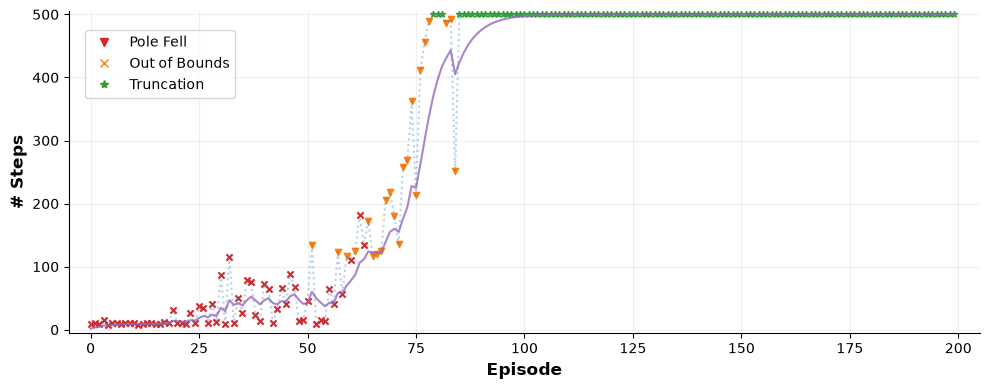

In [19]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

# Process data
# Extract the episode steps and ema from the recording.
_, train_steps = run_recording.scalar('episode/steps')
_, train_steps_ema = run_recording.scalar('episode/steps_ema')
TRAIN_EPOCHES = len(train_steps)
# Split the outcomes of the run into fell/oob/truncated
outcomes = [event['outcome'] for event in run_recording.events('episode_end')]
outcomes_array = np.array(outcomes)
x_pole = np.argwhere(outcomes_array == 'fell').reshape(-1)
y_pole = train_steps[x_pole]
x_oob = np.argwhere(outcomes_array == 'out of bounds').reshape(-1)
y_oob = train_steps[x_oob]
x_trnc = np.argwhere(outcomes_array == 'truncated').reshape(-1)
y_trnc = train_steps[x_trnc]

s = np.arange(TRAIN_EPOCHES)
ts = np.array(train_steps)

fig = plt.figure(figsize=(10,4))
# General curve
plt.plot(s, train_steps, alpha=1/3, linestyle=':')
plt.plot(s, train_steps_ema, color='tab:purple', alpha=0.8)
# Pole-fell
plt.scatter(x_pole, y_pole, color='tab:red', s=20, alpha=1, marker='x')
# Agent out-of-bounds
plt.scatter(x_oob, y_oob, color='tab:orange', s=20, alpha=1, marker='v')
# Episode truncated
plt.scatter(x_trnc, y_trnc, color='tab:green', s=20, alpha=1, marker='*')

# Format plot
plt.xlim(-5, TRAIN_EPOCHES+5)
plt.ylim(-5, 505)
plt.xlabel('Episode', fontweight='bold', fontsize=12)
plt.ylabel('# Steps', fontweight='bold', fontsize=12)
plt.grid(alpha=0.2)
plt.tight_layout()

legend_elements = [
	Line2D([], [], color='tab:red', marker='v', linewidth=0, label='Pole Fell'), 
	Line2D([], [], color='tab:orange', marker='x', linewidth=0, label='Out of Bounds'), 
	Line2D([], [], color='tab:green', marker='*', linewidth=0, label='Truncation'), 
]
fig.legend(handles=legend_elements, ncols=1, bbox_to_anchor=(0.165, 0.825), loc='center', frameon=True)
plt.show()

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

A 1 to 1 correspondance with the original cartpole example!. 

However, this plot alone will not justify paying the extra compute time. Fortunately, the current probes can give us much much more information about what is going on in the model itself. Currently, we are tracking firing rates, rasters, potentials and many more. Let's see what is really in there.

</div>

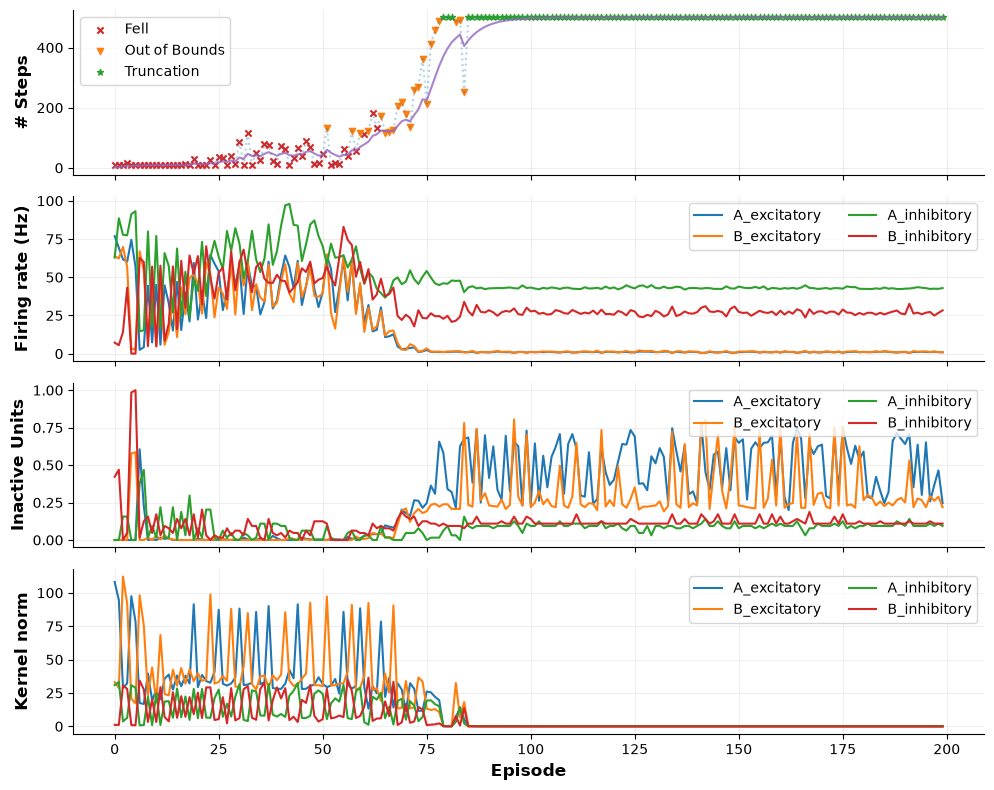

In [20]:
_, steps = run_recording.scalar('episode/steps')
_, ema = run_recording.scalar('episode/steps_ema')
outcomes = [event['outcome'] for event in run_recording.events('episode_end')]

fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

# Training curve
axs[0].plot(s, train_steps, alpha=1/3, linestyle=':')
axs[0].plot(s, train_steps_ema, color='tab:purple', alpha=0.8)
axs[0].scatter(x_pole, y_pole, color='tab:red', s=20, alpha=1, marker='x', label='Fell')
axs[0].scatter(x_oob, y_oob, color='tab:orange', s=20, alpha=1, marker='v', label='Out of Bounds')
axs[0].scatter(x_trnc, y_trnc, color='tab:green', s=20, alpha=1, marker='*', label='Truncation')
axs[0].set_ylabel('# Steps', fontweight='bold', fontsize=12)
axs[0].legend(loc='upper left')

# Episode firing rate.
for name in ('A_excitatory', 'B_excitatory', 'A_inhibitory', 'B_inhibitory'):
	_, rate = run_recording.scalar(f'summary/{name}.soma:spikes/active_fraction')
	axs[1].plot(rate * 1000, label=name)								# <--- rate per step to Hz (dt = 1 ms)
axs[1].set_ylabel('Firing rate (Hz)', fontweight='bold', fontsize=12)
axs[1].legend(loc='upper right', ncols=2)

# Episode inactive units.
for name in ('A_excitatory', 'B_excitatory', 'A_inhibitory', 'B_inhibitory'):
	_, inactive = run_recording.scalar(f'summary/{name}.soma:spikes/inactive_unit_fraction')
	axs[2].plot(inactive, label=name)								# <--- rate per step to Hz (dt = 1 ms)
axs[2].set_ylabel('Inactive Units', fontweight='bold', fontsize=12)
axs[2].legend(loc='upper right', ncols=2)								# <--- rate per step to Hz 

# Episode kernel norms.
for name in ('A_excitatory', 'B_excitatory', 'A_inhibitory', 'B_inhibitory'):
	_, norm = run_recording.scalar(f'summary/{name}.synapses.kernel/norm')
	axs[3].plot(norm, label=name)								# <--- rate per step to Hz (dt = 1 ms)
axs[3].set_ylabel('Kernel norm', fontweight='bold', fontsize=12)
axs[3].set_xlabel('Episode', fontweight='bold', fontsize=12)
axs[3].legend(loc='upper right', ncols=2)								# <--- rate per step to Hz 


for ax in axs:
	ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Moreover, our recorder was also tracking entire episodes which we can inspect in more detail!

</div>

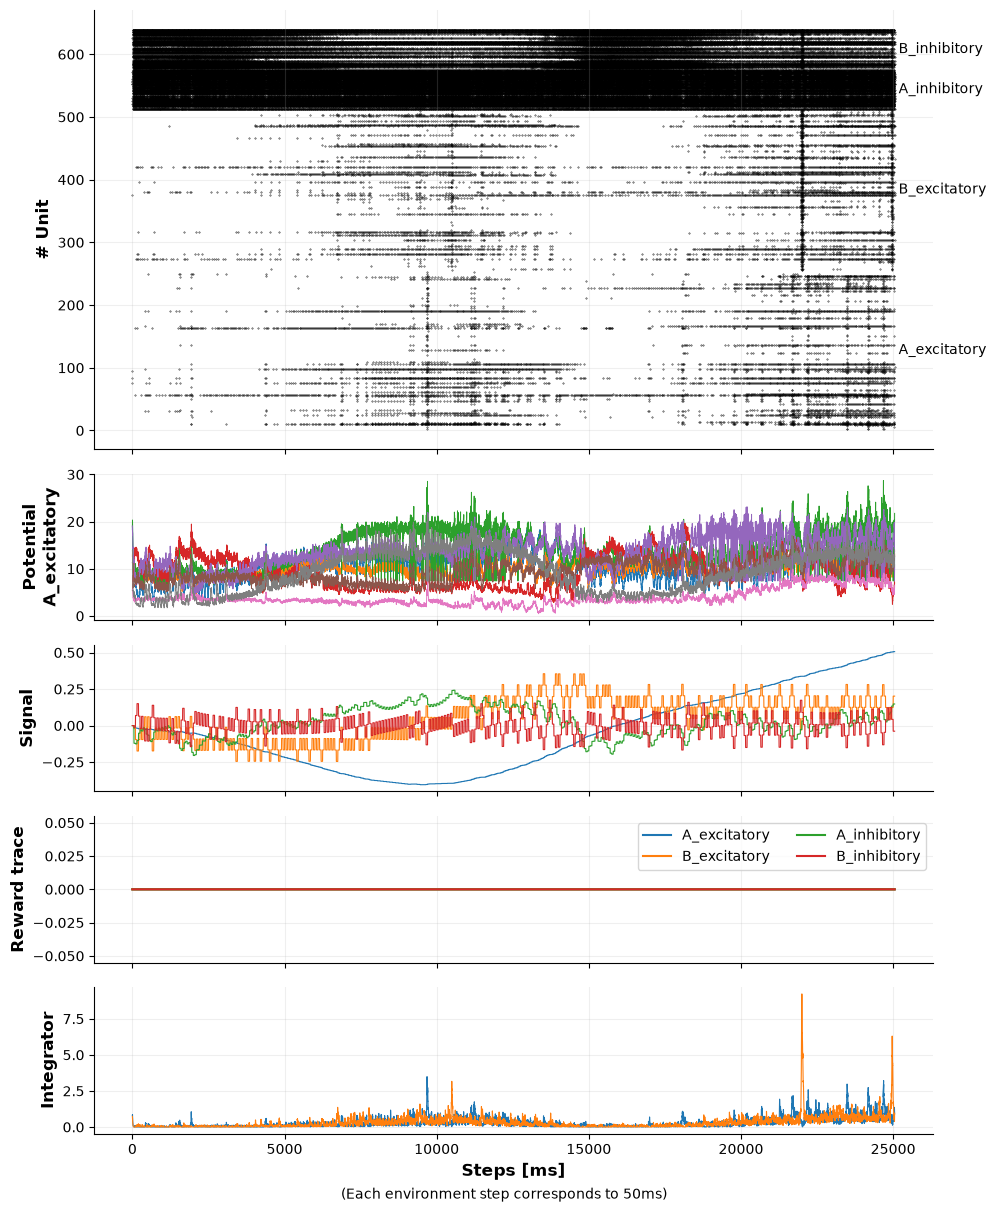

In [21]:
# Get the episode records.
episodes = run_recording.read('episode')
# ... and let's just focus on the last episode.
episode = episodes[max(episodes)]

fig, axs = plt.subplots(5, 1, figsize=(10, 12), sharex=True, height_ratios=[3, 1, 1, 1, 1])

# Spikes of every population, from their rasters: one bool per unit and step.
offset = 0
for name in ('A_excitatory', 'B_excitatory', 'A_inhibitory', 'B_inhibitory'):
	# Rasters are bundle in a row format (step, spikes)
	t, spikes = episode.rasters[f'{name}.soma:spikes']
	units = spikes.shape[1]
	step, unit = np.nonzero(spikes)
	axs[0].scatter(t[step], unit + offset, s=0.1, color='black')
	axs[0].text(t[-1], offset + units / 2, f' {name}', va='center')
	offset += units
axs[0].set_ylabel('# Unit', fontweight='bold', fontsize=12)

# A few membrane potentials.
t, potential = episode.traces['A_excitatory.soma.potential']
axs[1].plot(t, potential[:, :8], lw=0.7)
axs[1].set_ylabel('Potential\nA_excitatory', fontweight='bold', fontsize=12)

# What the network was seeing.
t, signal = episode.traces['__call__:signal']
axs[2].plot(t, signal, lw=0.8)
axs[2].set_ylabel('Signal', fontweight='bold', fontsize=12)

# The reward traces that drive plasticity.
for name in ('A_excitatory', 'B_excitatory', 'A_inhibitory', 'B_inhibitory'):
	t, reward = episode.traces[f'{name}.reward_trace:output']
	axs[3].plot(t, reward, label=name)
axs[3].set_ylabel('Reward trace', fontweight='bold', fontsize=12)
axs[3].legend(loc='upper right', ncols=2)

# And what it decided.
t, action = episode.traces['integrator:signal']
axs[4].plot(t, action, lw=0.8)
axs[4].set_ylabel('Integrator', fontweight='bold', fontsize=12)
axs[4].set_xlabel(f'Steps [ms]', fontweight='bold', fontsize=12)
fig.text(0.5, 0, '(Each environment step corresponds to 50ms)', va='center', ha='center')


for ax in axs:
	ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

We also have some snapshots of the kernels at the end of each (recorded) episode. Unlike any other measurement so far, these ones are really large, so we measure this ones sparsely, otherwise the recorder would bottleneck everything (and it is already taking its fair share of the pie!).

</div>

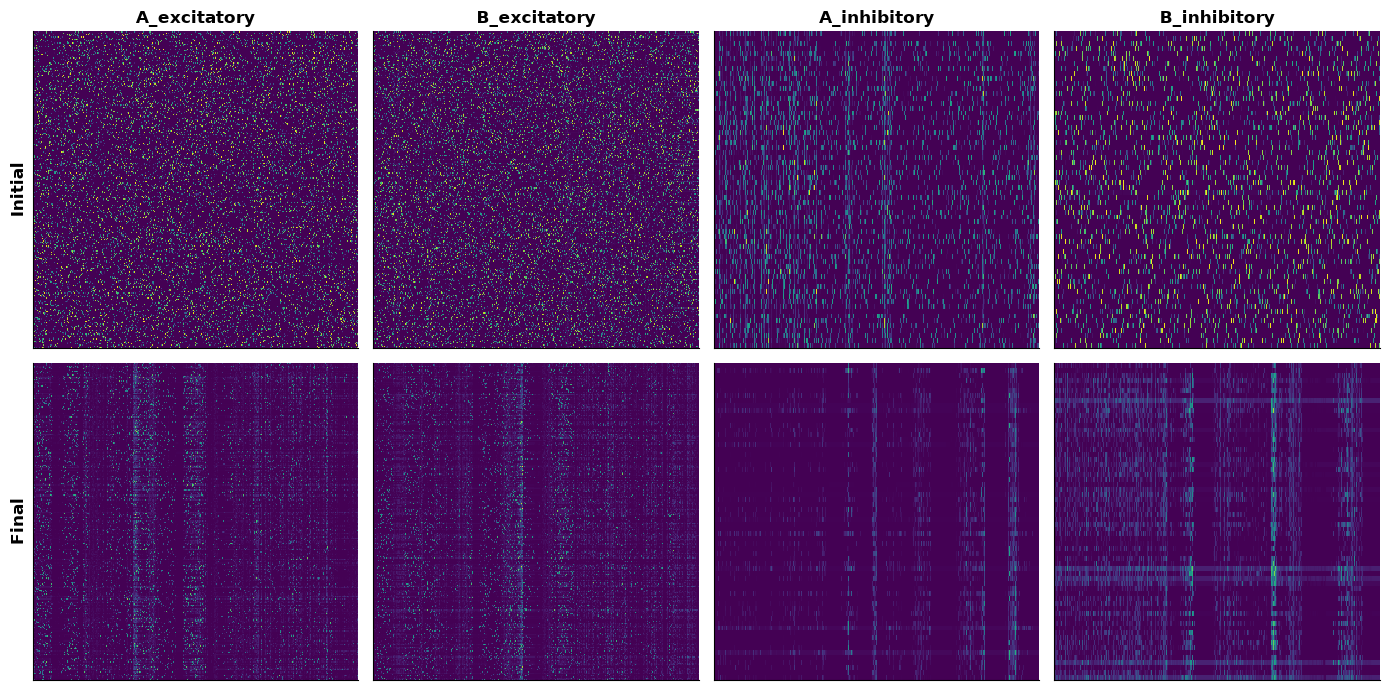

In [22]:
weights = run_recording.read('weights')
first = weights[0]
last = weights[max(weights)]

fig, ax = plt.subplots(2, 4, figsize=(14, 7))

# Initial kernel
for i, name in enumerate(('A_excitatory', 'B_excitatory', 'A_inhibitory', 'B_inhibitory')):
	ax[0, i].imshow(first.snapshots[f'{name}.synapses.kernel'], aspect='auto', interpolation='none')
	ax[0, i].set_title(name, fontweight='bold', fontsize=12)
	
# Final kernel
for i, name in enumerate(('A_excitatory', 'B_excitatory', 'A_inhibitory', 'B_inhibitory')):
	ax[1, i].imshow(last.snapshots[f'{name}.synapses.kernel'], aspect='auto', interpolation='none')

# Extra format
for r in ax:
	for p in r:
		p.set_xticks([])
		p.set_yticks([])
ax[0, 0].set_ylabel('Initial', fontweight='bold', fontsize=12)
ax[1, 0].set_ylabel('Final', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Plots are nice, but we spent the whole series building our models as graphs, so why not look at a run the same way? <b>spark.RunViewer</b> opens a run over the graph of its model:

Every node in the graph shows can show any tracked variable: summaries over the whole run, traces, rasters, histograms and weights. Importantly information is organized in a with a clean timeline, which shows what was recorded at each point in time for each node.

It also works while the run is still being written! The viewer can follow the run live. Moreover, the <b>Record</b> button can ask the recorder to record something right now, similar to <b>run.record(name, steps)</b> does from code; the request reaches the training loop through the run directory, so it works from another process too. The same viewer can be accessed through the Graph Editor, under <b>File > Open Run...</b>.

</div>

In [ ]:
# Feel free to explore the run!
#if __name__ == "__main__":
#    viewer = spark.RunViewer()
#    viewer.open(recorder.path)

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

A few more tricks for long runs:

<b>rec.When(condition, watch=...)</b> records a set of measurements when a condition is triggered, for example, when most of a population goes inactive. Importantly, since this condition is checked once the records reaches the host, it start recording after the condtion was triggered, which depending on the workload may be the next model call or a several model calls later. Fortunately, <b>lookback</b> can mitigate this effect by keeping track a few extra steps, which for the sake of efficiency are only kept in the GPU until they are actually needed.

</div>

In [24]:
inactive = lambda record: record.summaries['A_excitatory.soma:spikes'].inactive_unit_fraction > 0.9
collapse = rec.Measurements(
	'collapse',
	rec.presets.activity(brain, trace_units=32),
	trigger=rec.When(inactive, watch='summary', length=500),
	lookback=500,
)

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

In general lookback is perfect to see what led to an event! (... not only to fix the features)

For example, it is quite easy to create a probe that keeps track of what happens just before the pole falls.

</div>

In [25]:
# Set an activity measurement of the last 200 steps.
before_fall = rec.Measurements(
	'before_fall',
	rec.presets.activity(brain, trace_units=32),
	lookback=200,
)

# Written only after the pole falls.
with rec.Recorder('runs', brain_config, [*measurements, before_fall], name='lookback') as recorder:
	graph, state = spark.split((brain))
	for e in range(5):
		recorder.tag(episode=e)
		state, episode_steps, outcome = run_episode(env, graph, state, modulation_scale=1.0, steps=STEPS, unroll=UNROLL)
		if outcome == 'fell':
			recorder.record('before_fall')										# <--- The next call, and the 200 steps before it

falls = rec.load(recorder.path).read('before_fall')
falls[max(falls)]

Record 2100: steps 2100 to 2350 of the run (250 steps)
  traces
    A_excitatory.drift_trace:output   (250, 1) float16
    A_excitatory.reward_trace:output  (250, 1) float16
    A_excitatory.soma.potential       (250, 32) float16
    A_inhibitory.drift_trace:output   (250, 1) float16
    A_inhibitory.reward_trace:output  (250, 1) float16
    A_inhibitory.soma.potential       (250, 32) float16
    B_excitatory.drift_trace:output   (250, 1) float16
    B_excitatory.reward_trace:output  (250, 1) float16
    B_excitatory.soma.potential       (250, 32) float16
    B_inhibitory.drift_trace:output   (250, 1) float16
    B_inhibitory.reward_trace:output  (250, 1) float16
    B_inhibitory.soma.potential       (250, 32) float16
    __call__:drift_ex                 (250, 1) float16
    __call__:drift_in                 (250, 1) float16
    __call__:mod_a_ex                 (250, 1) float16
    __call__:mod_a_in                 (250, 1) float16
    __call__:mod_b_ex                 (250, 1) float

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

<b>recorder.checkpoint(state)</b> saves the state of the model into the run, and <b>run.restore(model)</b> brings it back, so a run can be resumed with <b>rec.Recorder.resume</b>.

</div>

In [26]:
# Save the state of the model into the run...
with rec.Recorder('runs', brain_config, measurements, name='checkpoint') as recorder:
	graph, state = spark.split((brain))
	for e in range(3):
		recorder.tag(episode=e)
		recorder.record('summary')
		state, episode_steps, outcome = run_episode(env, graph, state, modulation_scale=1.0, steps=STEPS, unroll=UNROLL)
		recorder.checkpoint(spark.merge(graph, state))							# <--- brain.checkpoint, filed under the current step

# ... and later on, maybe after a crash, bring it back and go on from there.
run_checkpoint = rec.load(recorder.path)
step = run_checkpoint.checkpoints()[-1]
restored = run_checkpoint.restore(step)											# <--- The brain, built again from the checkpoint
with rec.Recorder.resume(recorder.path, restored, step=step) as recorder:		# <--- The run goes on from the step of the checkpoint
	graph, state = spark.split((restored))
	for e in range(3, 6):
		recorder.tag(episode=e)
		recorder.record('summary')
		state, episode_steps, outcome = run_episode(env, graph, state, modulation_scale=1.0, steps=STEPS, unroll=UNROLL)

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

* When a pattern is regular, a trigger can do the asking for us: <b>rec.Measurements(..., trigger=rec.Every(20, unit='episode'))</b> replaces the <b>if</b> of our training loop. Triggers and <b>recorder.record</b> can be combined freely.

</div>

In [27]:
# The measurements of our training loop, asking for their own steps...
triggered = [
	rec.Measurements('summary', rec.presets.summary(brain), group='episode', trigger=rec.Always()),
	rec.Measurements('episode', rec.presets.activity(brain, trace_units=32), group='episode', raw=('env/observation',), trigger=rec.Every(20, tag='episode')),
	rec.Measurements('weights', rec.presets.weights(brain), group='episode', trigger=rec.Every(20, tag='episode')),
]

# ... and a training loop without a single if.
with rec.Recorder('runs', brain_config, triggered, name='triggers') as recorder:
	graph, state = spark.split((brain))
	for e in range(3):
		recorder.tag(episode=e)													# <--- The triggers count the episodes of this tag
		state, episode_steps, outcome = run_episode(env, graph, state, modulation_scale=1.0, steps=STEPS, unroll=UNROLL)

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

PROTIP: Each combination of recorded measurements compiles the first time it is recorded. <b>warmup</b> compiles ahead of time the combinations that are likely to be recorded, so that no compilation happens mid-run:

</div>

In [28]:
with rec.Recorder('runs', brain_config, measurements) as recorder:
	run_model_unroll.warmup(graph, state, steps=STEPS, unroll=UNROLL, **mod_inputs(np.zeros(4), drift=0.0))

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

A few things worth keeping in mind:

* Each distinct combination of recorded measurements is compiled once. Try to keep measurements multiples of each other to minimize the number of compilations. For example, having 3 different measurements every A, B and C times may either compile to {A}, {A, B} and {A, B, C} if B is a multiple of A and C is a multiple of A and B; similarly, if all three are independent, this could potentially produce 6 different compilations: {A}, {B}, {C}, {A, B}, {B, C} and {A, B, C}.
* Summaries, traces of a few neurons and rasters are cheap. Snapshots of large weight matrices are limited by the transfer out of the GPU, so record them rarely.
* Records are copied to the host and written on a separate thread, so the model never waits for them.

🎉 Congratulations! 🎉

Now you can watch your SNNs learn, not just count how long the pole stays up!

</div>